In [37]:
data_dir = '/scratch/mjehangir/Glioma_project/severus/severus_out/sv_annotation/'

In [38]:
setwd(data_dir)

In [10]:
library(circlize)
library(dplyr)
library(tidyr)


In [11]:
# Load the data
library(dplyr)
data <- read.delim("/scratch/mjehangir/Glioma_project/severus/severus_out/shared_svs_summary.tsv", header = TRUE, sep = "\t")



In [79]:
head(data)

,cluster_id,event_id,sv_type,det_sv_type,chr_pair,n_samples,samples
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>
1,svcluster_1,chr12:108158448|chr12:119140724::BND,BND,None,chr12_chr12,1,6439C
2,svcluster_2,chr11:118214613|chr11:121355870::BND,BND,None,chr11_chr11,1,6365A
3,svcluster_3,chr14:76151679|chr5:163310229::BND,BND,None,chr14_chr5,1,3188
4,svcluster_4,chr14:91638652|chr5:31573785::BND,BND,complex_inv,chr14_chr5,1,3188
5,svcluster_5,chr10:101880478|chr10:60384587::BND,BND,complex_inv,chr10_chr10,1,6414C
6,svcluster_6,chr10:34046401|chr6:70365187::BND,BND,Templated_ins,chr10_chr6,1,6277A


In [105]:
# Step 1: Expand samples and filter det_sv_type
data_long <- data %>%
  separate_rows(samples, sep = ",") %>%
  filter(!det_sv_type %in% c("Templated_ins_inv", "Templated_ins", "None", "", NA))

library(stringr)

# Extract chr2 and pos2 by capturing groups
matches <- str_match(data_long$event_id, "chr[0-9XYM]+:(\\d+)\\|chr([0-9XYM]+):(\\d+)")

# The str_match result columns:
# [,1] = full match
# [,2] = pos1 (first number)
# [,3] = chr2 (second chromosome without "chr" prefix though)
# [,4] = pos2 (second number)

# So, to get chr2 with 'chr' prefix, prepend "chr" back:
data_long <- data_long %>%
  mutate(
    chr1 = str_extract(event_id, "^chr[0-9XYM]+"),
    pos1 = as.numeric(str_match(event_id, "^chr[0-9XYM]+:(\\d+)")[,2]),
    chr2 = paste0("chr", matches[,3]),
    pos2 = as.numeric(matches[,4])
  )

# Step 3: Assign colors for each det_sv_type
det_sv_colors <- RColorBrewer::brewer.pal(n = length(unique(data_long$det_sv_type)), name = "Set2")
names(det_sv_colors) <- unique(data_long$det_sv_type)

pdf("/home/mjehangir/glioma_manuscript/circos_plot_updated.pdf", width = 8, height = 8)
# Step 4: Initialize circos plot with ideogram (for hg38)
circos.clear()
circos.par(gap.after = c(rep(1, 23), 5))  # Optional: larger gap after chrX
circos.initializeWithIdeogram(species = "hg38")  # Or customize if using another genome

# Step 5: Plot links
circos.genomicLink(
  region1 = data_long %>% select(chr1, pos1, pos1),
  region2 = data_long %>% select(chr2, pos2, pos2),
  col = det_sv_colors[data_long$det_sv_type],
  border = NA
)

# Add legend (optional)
legend("topleft", legend = names(det_sv_colors), col = det_sv_colors, lty = 1, lwd = 2, cex = 0.8)
dev.off()

Note: The first link end is drawn out of sector 'chr18'.

Note: The second link end is drawn out of sector 'chr18'.

Note: The first link end is drawn out of sector 'chr4'.

Note: The second link end is drawn out of sector 'chr4'.

Note: The second link end is drawn out of sector 'chr8'.

Note: The second link end is drawn out of sector 'chr8'.

Note: The first link end is drawn out of sector 'chr18'.

Note: The second link end is drawn out of sector 'chr18'.

Note: The second link end is drawn out of sector 'chr9'.

Note: The second link end is drawn out of sector 'chr17'.

Note: The first link end is drawn out of sector 'chr22'.

Note: The first link end is drawn out of sector 'chr8'.

Note: The first link end is drawn out of sector 'chr9'.

Note: The second link end is drawn out of sector 'chr9'.

Note: The first link end is drawn out of sector 'chr4'.

Note: The second link end is drawn out of sector 'chr4'.



pdf 
  2

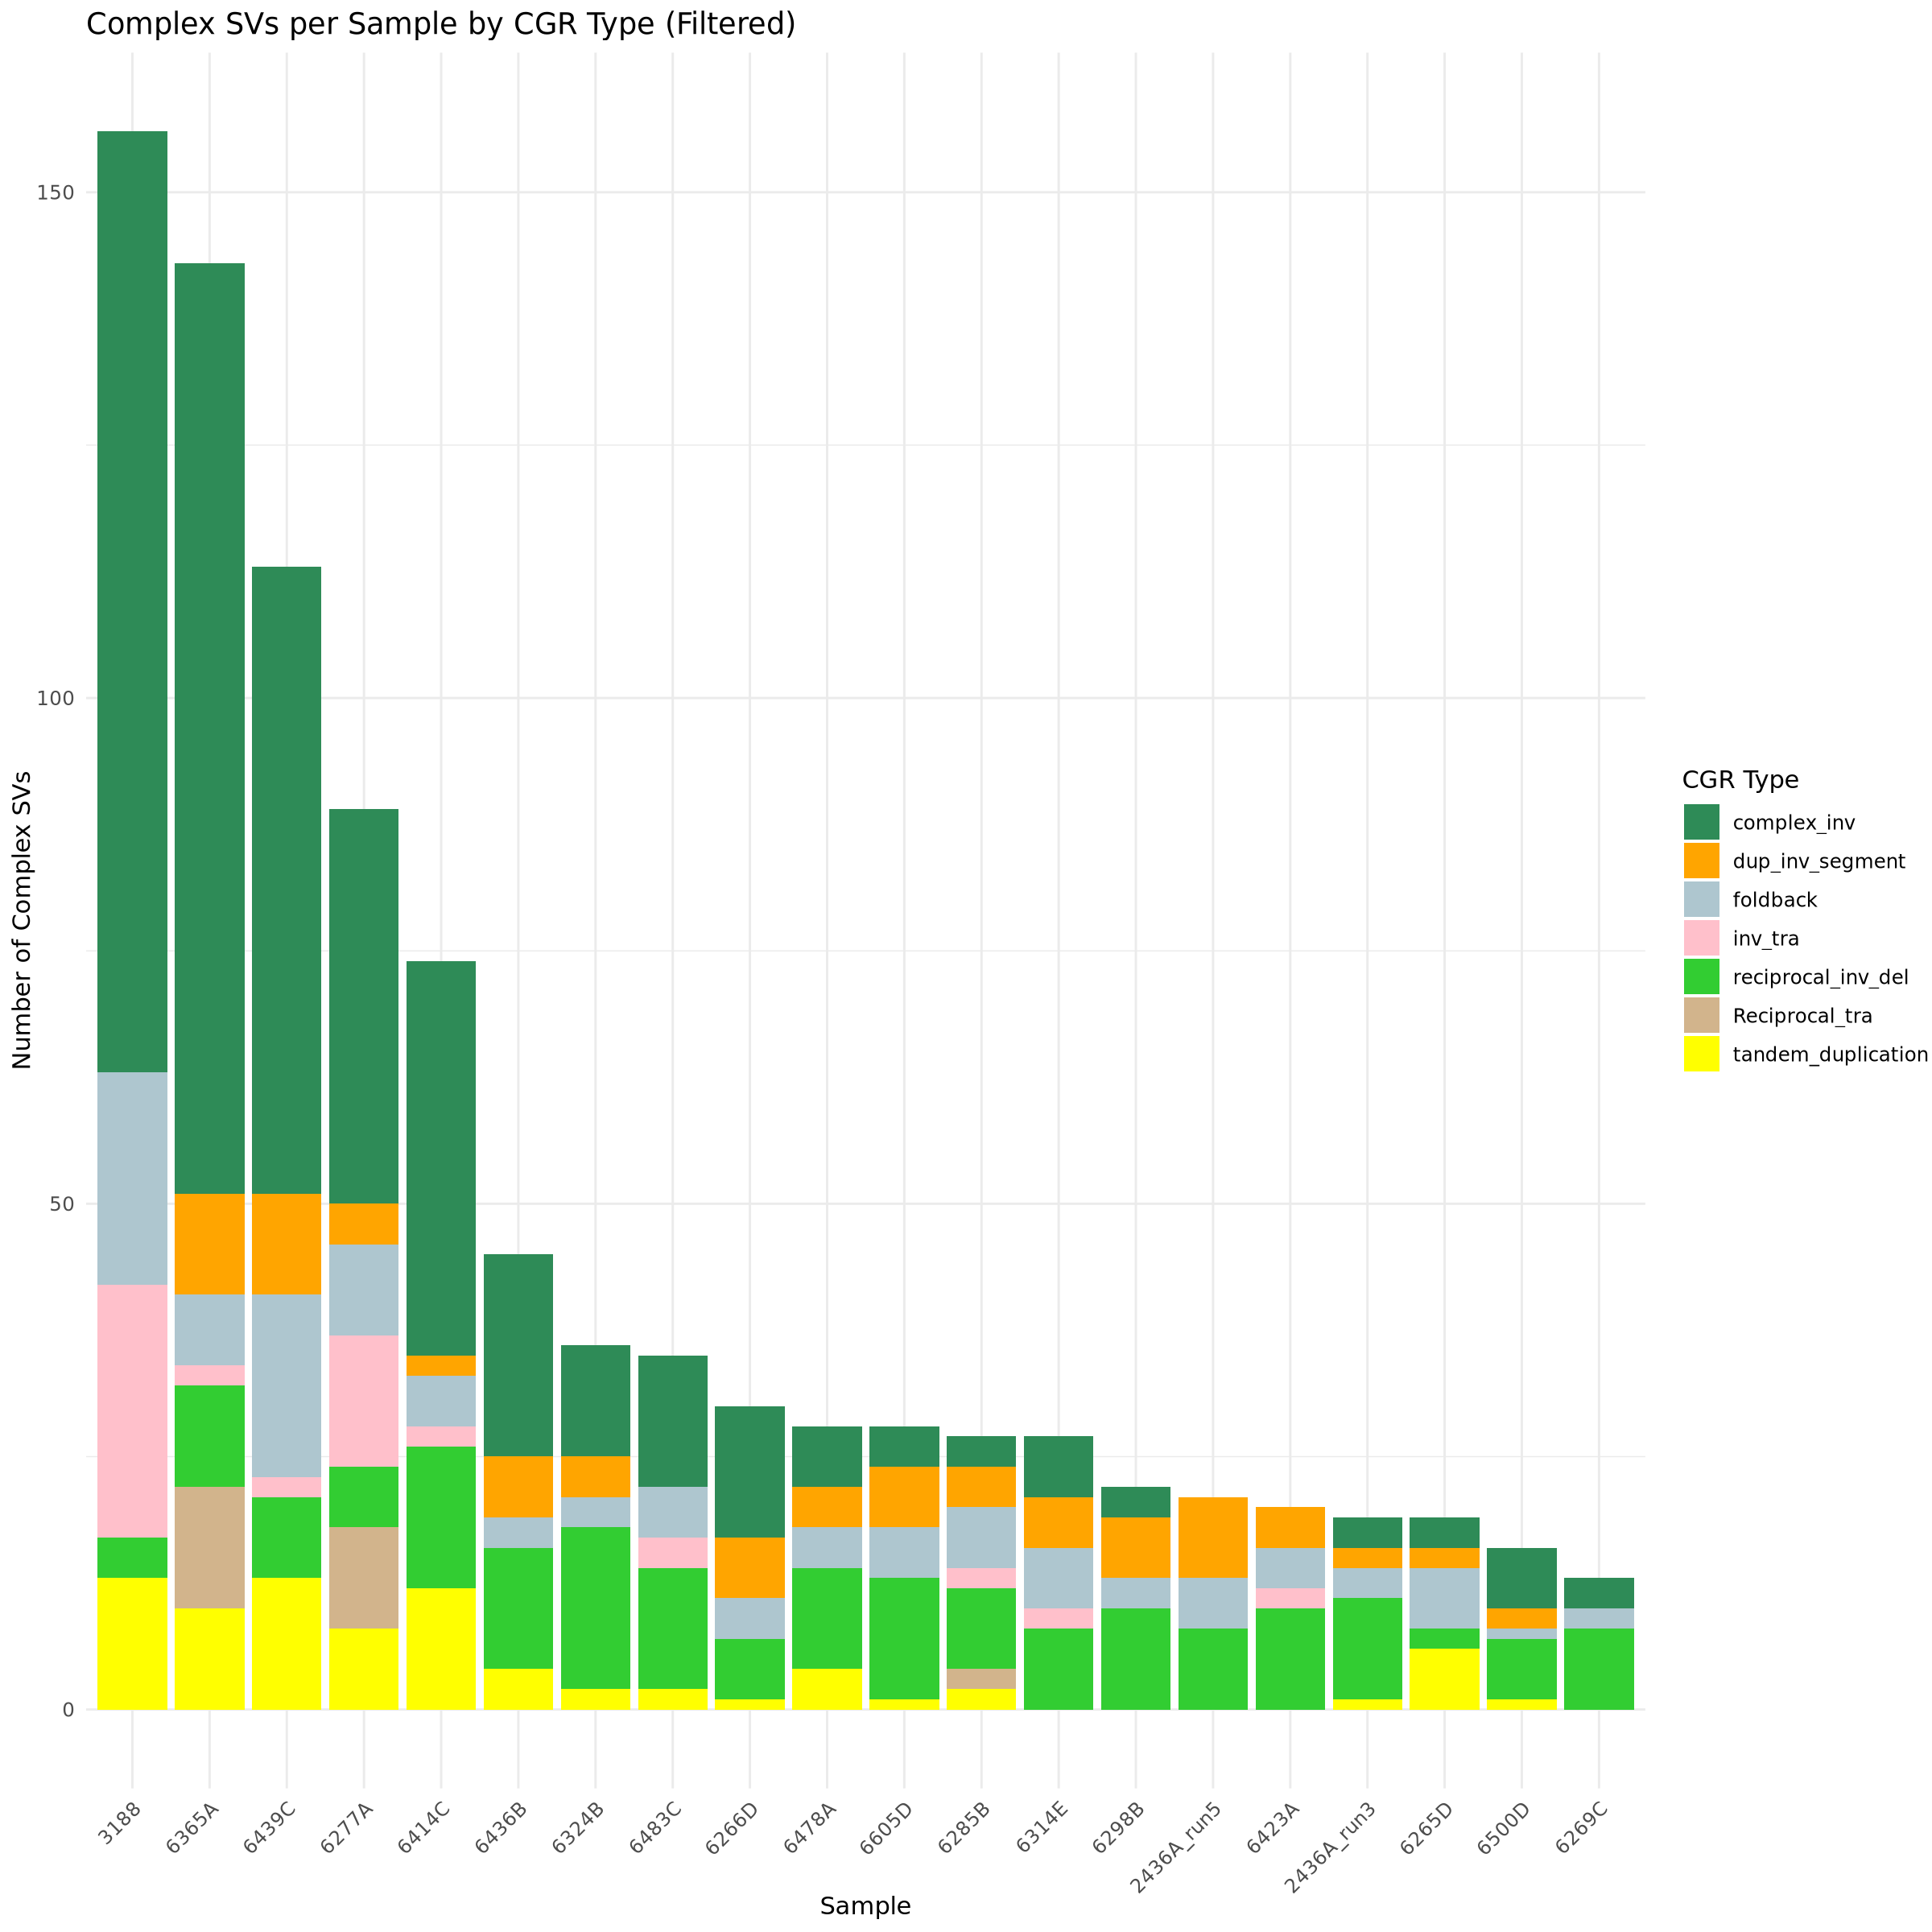

In [104]:
library(dplyr)
library(tidyr)
library(ggplot2)

# Filter out unwanted SV subtypes from your data before expanding samples
data_long <- data %>%
  tidyr::separate_rows(samples, sep = ",") %>%
  filter(
    !det_sv_type %in% c("Templated_ins_inv", "Templated_ins", "None", "", NA)
  )

# Count SVs per sample and subtype
sv_summary <- data_long %>%
  group_by(samples, det_sv_type) %>%
  summarise(n_SVs = n(), .groups = "drop")

# Order samples by total SV counts descending
sample_order <- sv_summary %>%
  group_by(samples) %>%
  summarise(total_SVs = sum(n_SVs)) %>%
  arrange(desc(total_SVs)) %>%
  pull(samples)

sv_summary$samples <- factor(sv_summary$samples, levels = sample_order)

color_map <- c(
  "complex_inv"        = "seagreen",  # green (ForestGreen)
  "dup_inv_segment"    = "#FFA500",  # orange
  "foldback"           = "#AEC6CF",  # light blue / periwinkle
  "inv_tra"            = "#FFC0CB",  # pink
  "reciprocal_inv_del" = "#32CD32",  # lime green (LimeGreen)
  "tandem_duplication" = "#FFFF00",  # yellow
  "Reciprocal_tra"     = "#D2B48C"   # tan / light brown (Tan)
)

p <- ggplot(sv_summary, aes(x = samples, y = n_SVs, fill = det_sv_type)) +
  geom_bar(stat = "identity") +
  theme_minimal() +
  scale_fill_manual(values = color_map) +  # <-- Use your custom colors here!
  labs(
    title = "Complex SVs per Sample by CGR Type (Filtered)",
    x = "Sample",
    y = "Number of Complex SVs",
    fill = "CGR Type"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

print(p)

# Save to PDF
ggsave("/home/mjehangir/glioma_manuscript/complex_SVs_per_sample.pdf", plot = p, width = 10, height = 6, dpi = 300)


In [81]:
print(paste("CGR Type:", sv_type, "Sample:", sample_id, "SVs:", nrow(sv_subset)))


ERROR: Error: object 'sample_id' not found


In [ ]:
nrow(data)

In [ ]:
unique(data$sv_type)

Warning message:
“Expected 2 pieces. Additional pieces discarded in 1621 rows [1, 2, 3, 4, 5, 6,
7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”


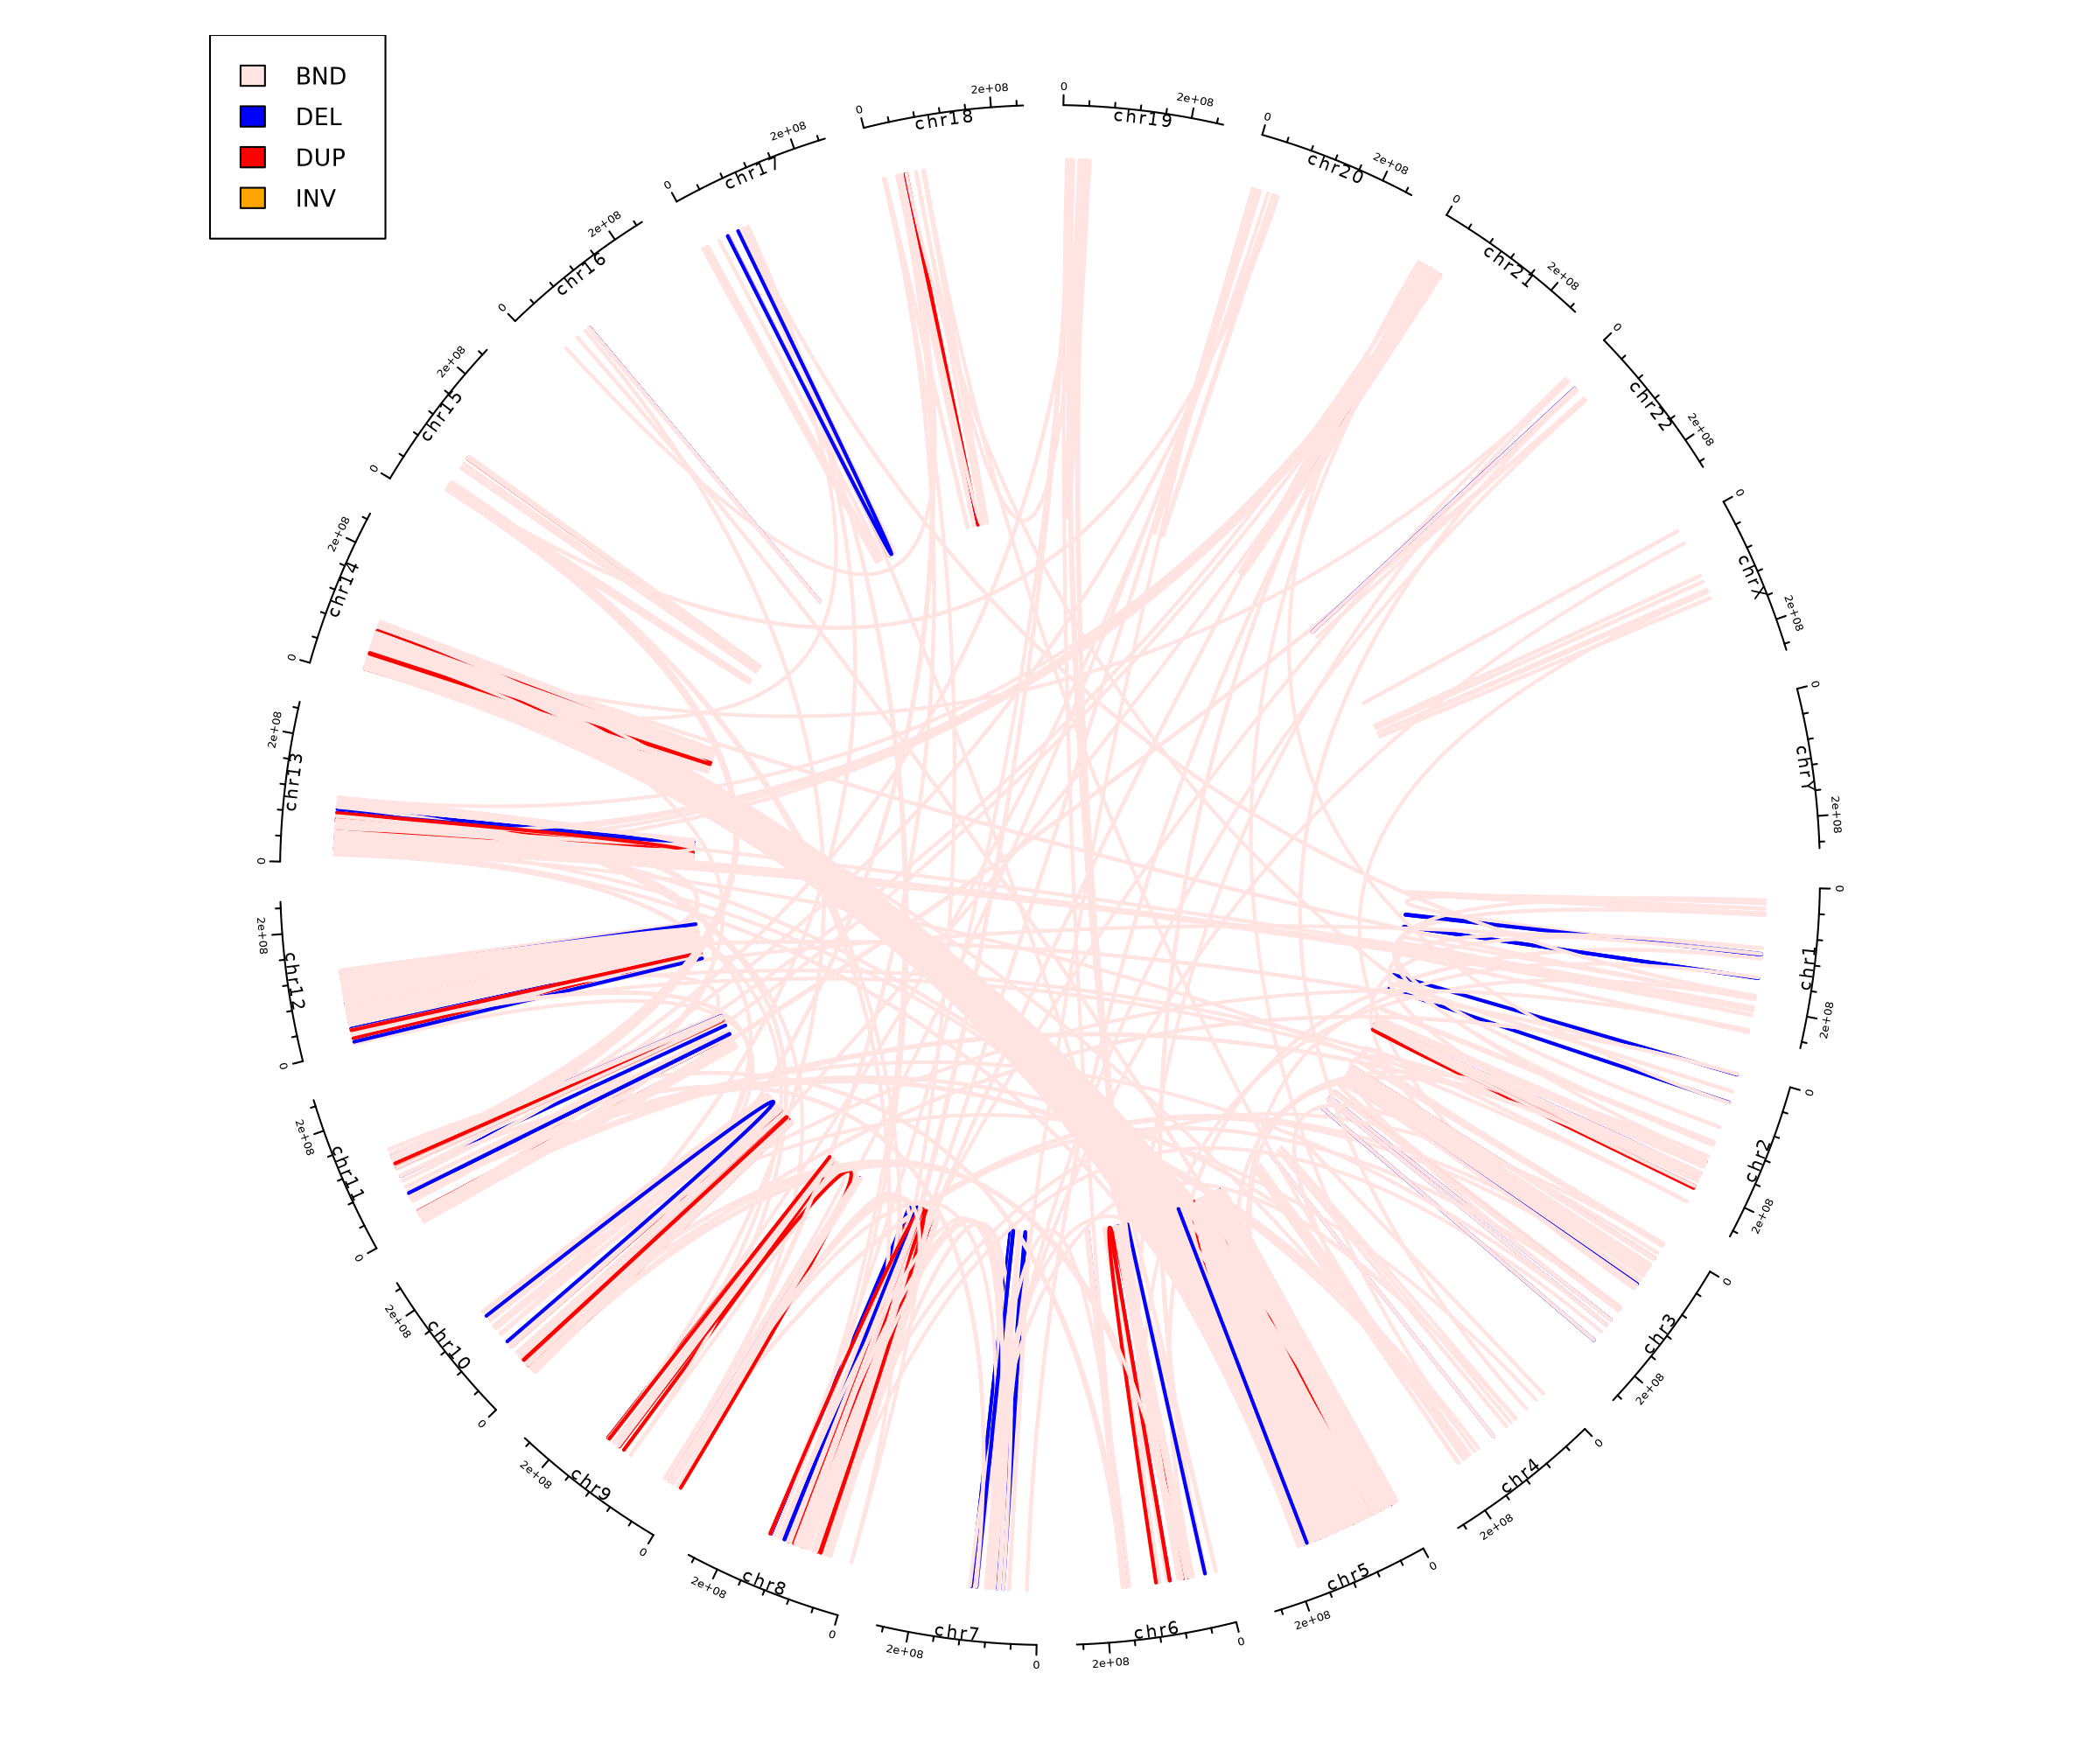

In [15]:
# ==== Parse Event Positions ====
sv_data_parsed <- data %>%
  separate(event_id, into = c("pos1", "pos2"), sep = "\\|") %>%
  separate(pos1, into = c("chr1", "start1"), sep = ":", convert = TRUE) %>%
  separate(pos2, into = c("chr2", "start2"), sep = ":", convert = TRUE)

# ==== Define Chromosomes and Lengths ====
chromosomes <- paste0("chr", c(1:22, "X", "Y"))
chrom_lengths <- rep(250e6, length(chromosomes))  # dummy lengths for visualization

# ==== Start PDF Output (Optional) ====
# pdf("circos_sv_plot.pdf", width = 8, height = 8)
options(repr.plot.width = 12, repr.plot.height = 10, repr.plot.res = 200)

# ==== Initialize Circos Plot ====
circos.clear()
circos.par("track.height" = 0.05)

circos.initialize(factors = chromosomes, xlim = cbind(rep(0, length(chromosomes)), chrom_lengths))

# ==== Add Chromosome Labels ====
circos.trackPlotRegion(ylim = c(0, 1), panel.fun = function(x, y) {
  chr = CELL_META$sector.index
  xlim = CELL_META$xlim
  circos.text(mean(xlim), 1.2, chr, facing = "bending.inside", niceFacing = TRUE, cex = 0.6)
  circos.axis(labels.cex = 0.4)
}, bg.border = NA)

# ==== Draw SV Links ====
for (i in 1:nrow(sv_data_parsed)) {
  chr1 <- sv_data_parsed$chr1[i]
  chr2 <- sv_data_parsed$chr2[i]
  start1 <- as.numeric(sv_data_parsed$start1[i])
  start2 <- as.numeric(sv_data_parsed$start2[i])
  sv_type <- sv_data_parsed$sv_type[i]

  color <- case_when(
    sv_type == "BND" ~ "mistyrose1",
    sv_type == "DEL" ~ "blue",
    sv_type == "DUP" ~ "red",
    sv_type == "INV" ~ "orange",
    TRUE ~ "gray"
  )

  circos.link(chr1, c(start1, start1 + 1), chr2, c(start2, start2 + 1), col = color, lwd = 2)
}

# ==== Add Legend ====
legend("topleft", legend = c("BND", "DEL", "DUP", "INV"),
       fill = c("mistyrose1", "blue", "red", "orange"), border = "black", cex = 0.8)

# ==== End PDF Output (Uncomment if used) ====
# dev.off()



In [16]:
head(data)

,cluster_id,event_id,sv_type,det_sv_type,chr_pair,n_samples,samples
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>
1,svcluster_1,chr12:108158448|chr12:119140724::BND,BND,None,chr12_chr12,1,6439C
2,svcluster_2,chr11:118214613|chr11:121355870::BND,BND,None,chr11_chr11,1,6365A
3,svcluster_3,chr14:76151679|chr5:163310229::BND,BND,None,chr14_chr5,1,3188
4,svcluster_4,chr14:91638652|chr5:31573785::BND,BND,complex_inv,chr14_chr5,1,3188
5,svcluster_5,chr10:101880478|chr10:60384587::BND,BND,complex_inv,chr10_chr10,1,6414C
6,svcluster_6,chr10:34046401|chr6:70365187::BND,BND,Templated_ins,chr10_chr6,1,6277A


In [85]:
library(dplyr)
library(readr)
library(ggplot2)

# Load your data


# Filter for clusters found in more than 2 samples
filtered_clusters <- data %>%
  filter(n_samples > 2) %>%
  select(cluster_id, sv_type, n_samples, det_sv_type, chr_pair)

# Count how many clusters of each SV type are shared
sv_type_summary <- filtered_clusters %>%
  group_by(sv_type) %>%
  summarise(num_clusters = n()) %>%
  arrange(desc(num_clusters))


In [86]:
# Print filtered clusters in descending order of n_samples
filtered_clusters %>%
  arrange(desc(n_samples)) %>%
  print()


       cluster_id sv_type n_samples        det_sv_type    chr_pair
1   svcluster_849     BND        15 reciprocal_inv_del chr21_chr21
2  svcluster_1135     BND        15 reciprocal_inv_del chr21_chr21
3   svcluster_962     BND        12           foldback chr11_chr11
4   svcluster_407     BND         9               None   chr3_chr3
5   svcluster_562     BND         9 reciprocal_inv_del   chr6_chr6
6   svcluster_782     BND         9 reciprocal_inv_del   chr6_chr6
7   svcluster_922     BND         9           foldback   chr3_chr3
8  svcluster_1156     BND         9               None chr12_chr12
9   svcluster_352     BND         8        complex_inv chr11_chr11
10  svcluster_369     BND         8 reciprocal_inv_del   chr1_chr1
11  svcluster_389     BND         8        complex_inv chr11_chr11
12  svcluster_619     BND         8        complex_inv chr11_chr11
13 svcluster_1279     BND         8 reciprocal_inv_del   chr1_chr1
14  svcluster_747     BND         7 reciprocal_inv_del   chr3_

In [87]:
head(filtered_clusters)

,cluster_id,sv_type,n_samples,det_sv_type,chr_pair
,<chr>,<chr>,<int>,<chr>,<chr>
1,svcluster_92,BND,3,reciprocal_inv_del,chr7_chr7
2,svcluster_119,BND,3,foldback,chr5_chr5
3,svcluster_258,DEL,3,,chr12_chr12
4,svcluster_337,BND,5,dup_inv_segment,chr9_chr9
5,svcluster_352,BND,8,complex_inv,chr11_chr11
6,svcluster_369,BND,8,reciprocal_inv_del,chr1_chr1


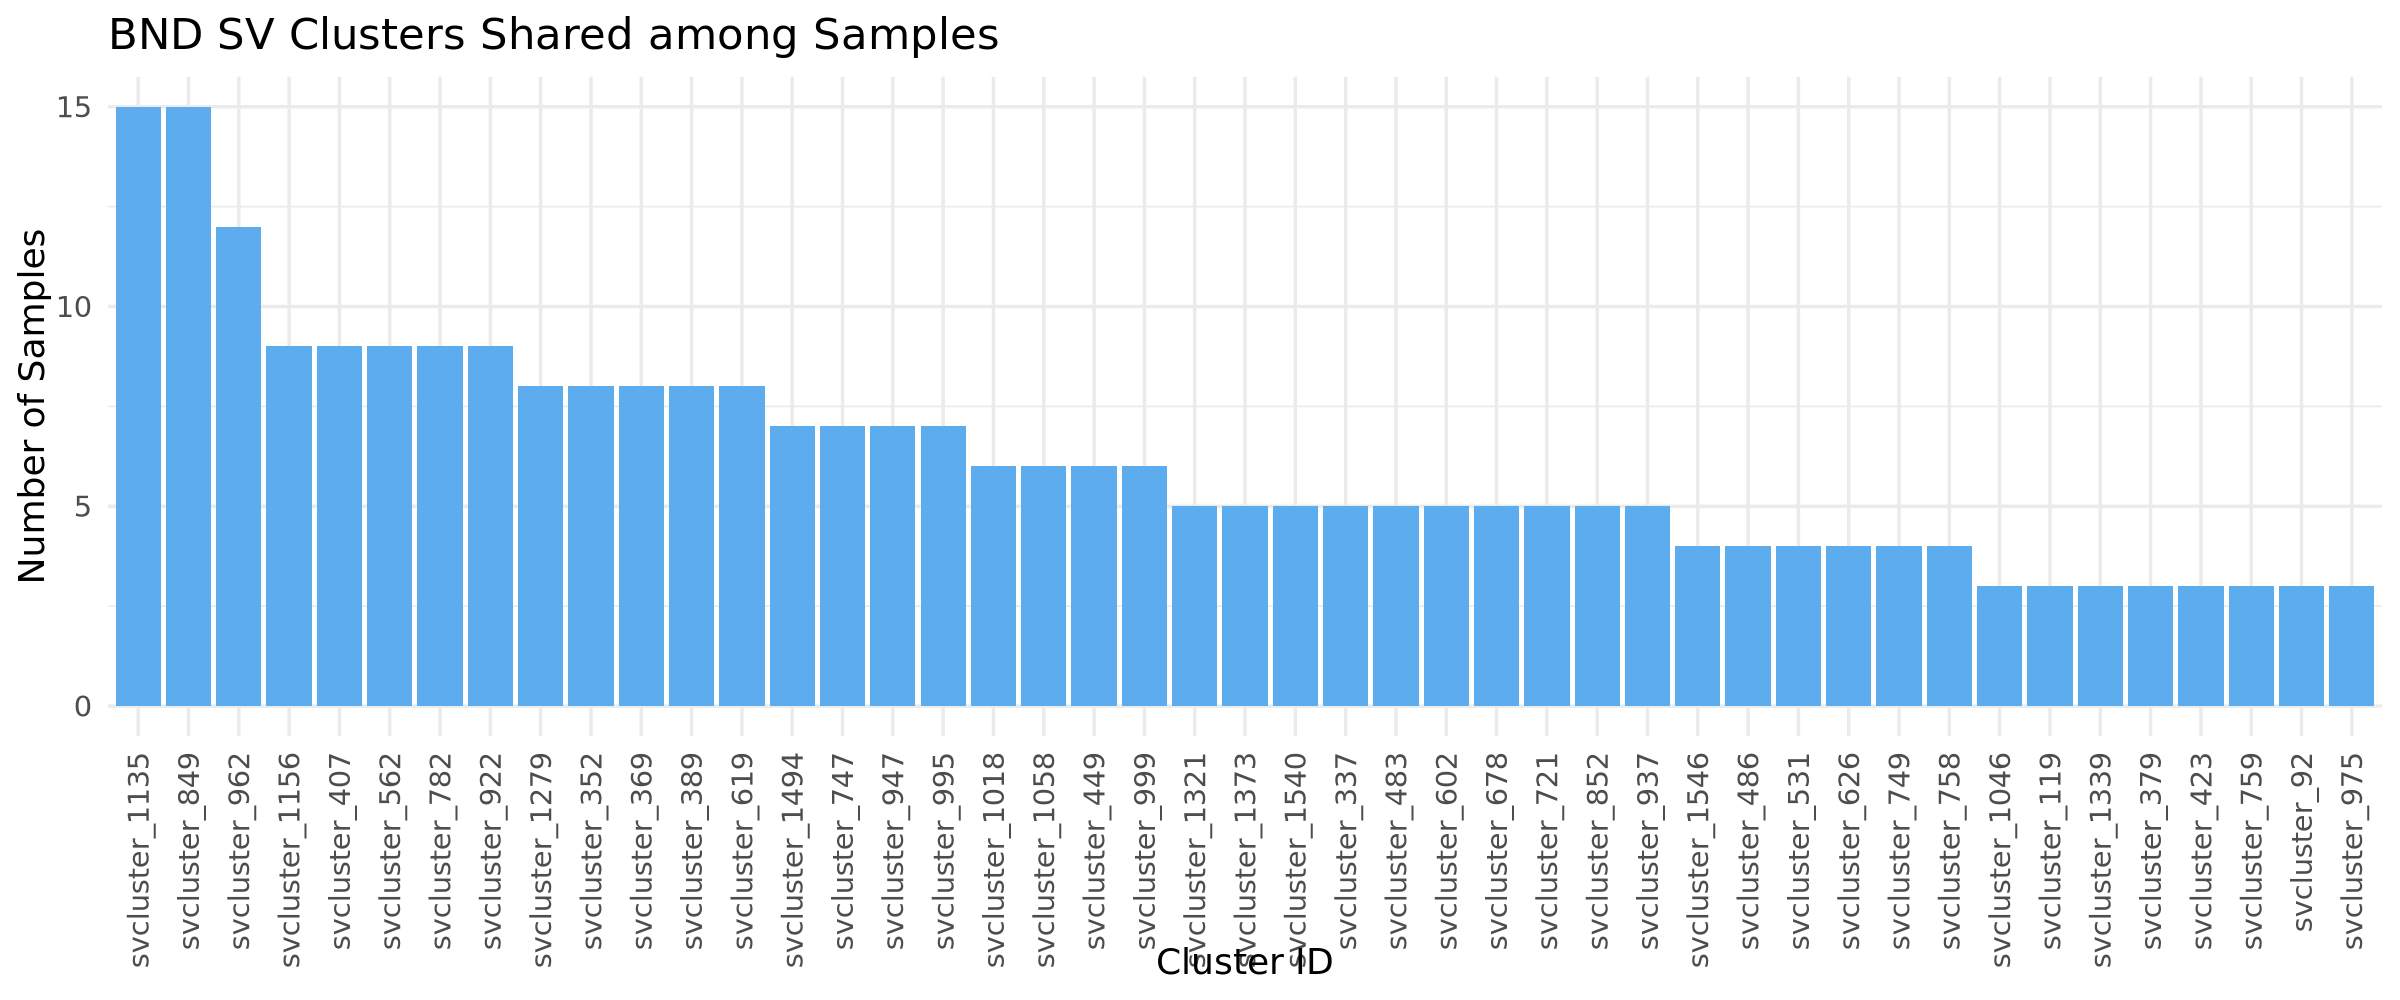

In [88]:
library(ggplot2)

options(repr.plot.width = 12, repr.plot.height = 5, repr.plot.res = 200)
library(ggplot2)
library(dplyr)

# 1. Filter to BND events
bnd_data <- filtered_clusters %>% 
  filter(sv_type == "BND")

# 2. Reorder cluster_id by descending n_samples
bnd_data <- bnd_data %>% 
  mutate(cluster_id = reorder(cluster_id, -n_samples))

# 3a. Vertical bar plot (rotate x‑labels)
ggplot(bnd_data, aes(x = cluster_id, y = n_samples)) +
  geom_col(fill = "steelblue2") +
  labs(
    title = "BND SV Clusters Shared among Samples",
    x     = "Cluster ID",
    y     = "Number of Samples"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)
  )


In [89]:
head(bnd_data) 

,cluster_id,sv_type,n_samples,det_sv_type,chr_pair
,<fct>,<chr>,<int>,<chr>,<chr>
1,svcluster_92,BND,3,reciprocal_inv_del,chr7_chr7
2,svcluster_119,BND,3,foldback,chr5_chr5
3,svcluster_337,BND,5,dup_inv_segment,chr9_chr9
4,svcluster_352,BND,8,complex_inv,chr11_chr11
5,svcluster_369,BND,8,reciprocal_inv_del,chr1_chr1
6,svcluster_379,BND,3,dup_inv_segment,chr16_chr16


In [90]:
bnd_top3_cluster =  bnd_data %>%
  arrange(desc(n_samples)) %>%
  head(n=10)

In [91]:
print(bnd_top3_cluster)

       cluster_id sv_type n_samples        det_sv_type    chr_pair
1   svcluster_849     BND        15 reciprocal_inv_del chr21_chr21
2  svcluster_1135     BND        15 reciprocal_inv_del chr21_chr21
3   svcluster_962     BND        12           foldback chr11_chr11
4   svcluster_407     BND         9               None   chr3_chr3
5   svcluster_562     BND         9 reciprocal_inv_del   chr6_chr6
6   svcluster_782     BND         9 reciprocal_inv_del   chr6_chr6
7   svcluster_922     BND         9           foldback   chr3_chr3
8  svcluster_1156     BND         9               None chr12_chr12
9   svcluster_352     BND         8        complex_inv chr11_chr11
10  svcluster_369     BND         8 reciprocal_inv_del   chr1_chr1


In [94]:
options(repr.plot.width = 12, repr.plot.height = 12, repr.plot.res = 200)

library(circlize)
library(dplyr)
library(tidyr)
library(stringr)

# 1. Read in your full data
data <- read.delim(
  "/scratch/mjehangir/Glioma_project/severus/severus_out/shared_svs_summary.tsv",
  header = TRUE, sep = "\t", stringsAsFactors = FALSE
)

# 2. Cleanly parse “chr:pos” (strip ::SVTYPE first)
sv_data <- data %>%
  mutate(evt = str_remove(event_id, "::.*$")) %>%
  separate(evt,   into = c("pos1","pos2"), sep = "\\|") %>%
  separate(pos1,  into = c("chr1","start1"), sep = ":", convert = TRUE) %>%
  separate(pos2,  into = c("chr2","start2"), sep = ":", convert = TRUE) %>%
  select(chr1, start1, chr2, start2)

# 3. Define true chromosome lengths
chrom_lengths <- c(
  chr1  = 248956422, chr2  = 242193529, chr3  = 198295559,
  chr4  = 190214555, chr5  = 181538259, chr6  = 170805979,
  chr7  = 159345973, chr8  = 145138636, chr9  = 138394717,
  chr10 = 133797422, chr11 = 135086622, chr12 = 133275309,
  chr13 = 114364328, chr14 = 107043718, chr15 = 101991189,
  chr16 = 90338345,  chr17 = 83257441,  chr18 = 80373285,
  chr19 = 58617616,  chr20 = 64444167,  chr21 = 46709983,
  chr22 = 50818468,  chrX  = 156040895, chrY  = 57227415
)

# 4. Precompute safe “end” positions so we never overshoot
sv_data <- sv_data %>%
  mutate(
    end1 = pmin(start1 + 1, chrom_lengths[as.character(chr1)]),
    end2 = pmin(start2 + 1, chrom_lengths[as.character(chr2)])
  )

pdf("/home/mjehangir/glioma_manuscript/circos_sv_links.pdf", width = 8, height = 8)
# 5. Initialize the circos plot
circos.clear()
circos.par(track.height = 0.05)
circos.initialize(
  factors = names(chrom_lengths),
  xlim    = cbind(rep(0, length(chrom_lengths)), chrom_lengths)
)
circos.trackPlotRegion(
  ylim      = c(0, 1),
  panel.fun = function(x, y) {
    chr  <- CELL_META$sector.index
    xlim <- CELL_META$xlim
    circos.text(
      mean(xlim), 1.2, chr,
      facing     = "bending.inside",
      niceFacing = TRUE, cex = 0.6
    )
    circos.axis(labels.cex = 0.4)
  },
  bg.border = NA
)

# 6. Draw  links
for(i in seq_len(nrow(sv_type))) {
  r <- sv_data[i, ]
  circos.link(
    r$chr1, c(r$start1, r$end1),
    r$chr2, c(r$start2, r$end2),
    col = "mistyrose1", lwd = 2
  )
}

# 7. Legend (optional)
legend(
  "topleft",
  legend = "All SV links",
  fill   = "mistyrose1",
  border = "black", cex = 0.8
)
# Close the PDF device
dev.off()

Warning message in seq_len(nrow(sv_type)):
“first element used of 'length.out' argument”


ERROR: Error in seq_len(nrow(sv_type)): argument must be coercible to non-negative integer


[1] "." "." "." "." "." "."

CHROM,POS,SVTYPE,ANNOTATION,GENE,TRANSCRIPT,DETAIL,PRIORITY
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
NC_060925.1,296592,.,NA,NA,NA,NA,NA
NC_060925.1,305801,.,NA,NA,NA,NA,NA
NC_060925.1,325206,.,NA,NA,NA,NA,NA
NC_060925.1,364363,.,NA,NA,NA,NA,NA
NC_060925.1,364364,.,NA,NA,NA,NA,NA
NC_060925.1,364394,.,NA,NA,NA,NA,NA


# A tibble: 4 × 2
  ANNOTATION                Count
  <chr>                     <int>
1 NA                         6816
2 EXON_DEL                   1040
3 BIDIRECTIONAL_GENE_FUSION    39
4 GENE_FUSION                  24


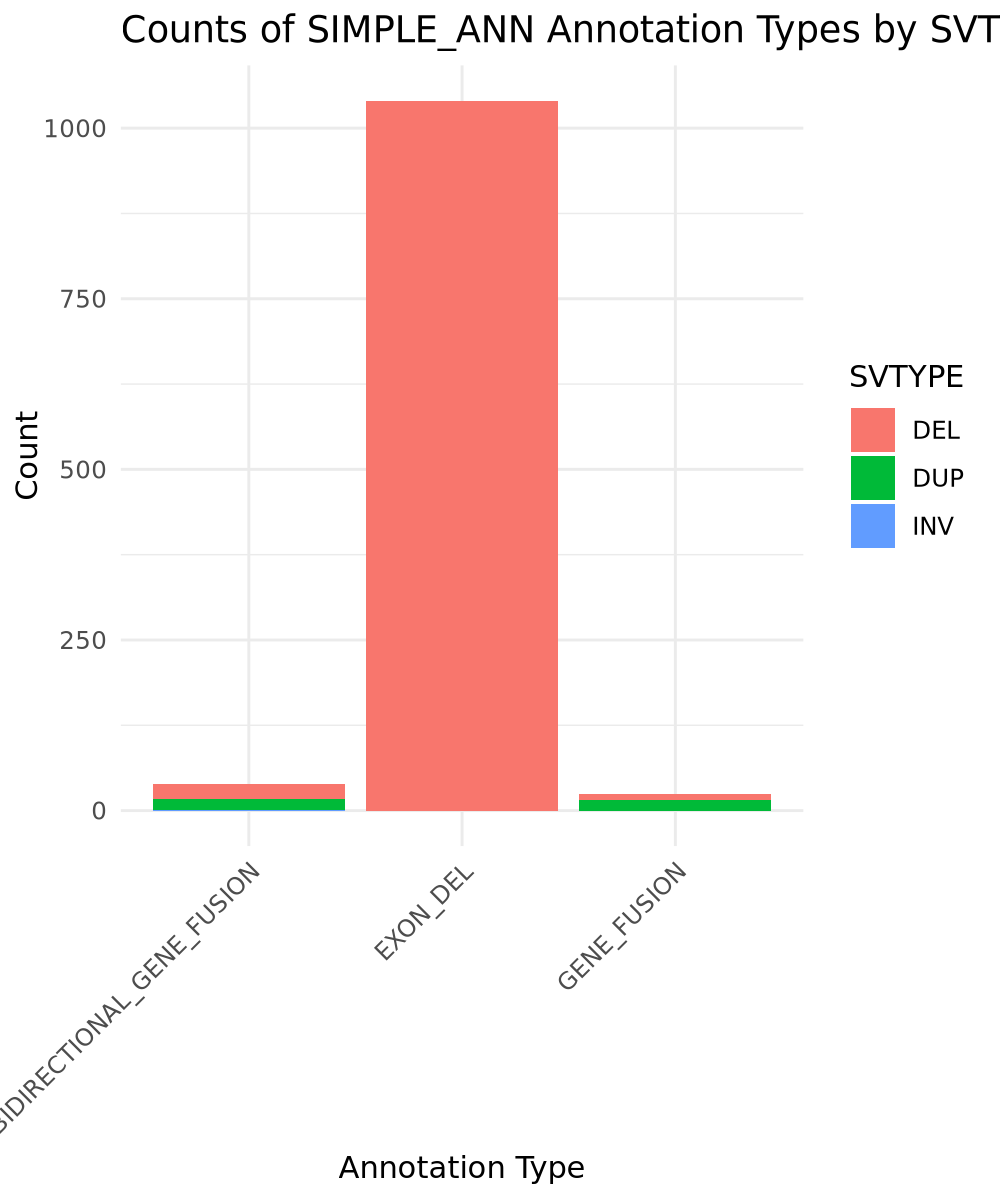

In [47]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(stringr)

# Read the TSV with at least columns: CHROM, POS, SIMPLE_ANN
df <- read.delim("simple_ann.tsv", header=FALSE, col.names=c("CHROM", "POS", "SIMPLE_ANN"), stringsAsFactors=FALSE)

# Check a few lines
head(df$SIMPLE_ANN)

# Separate multiple annotations (comma separated) into rows
df_expanded <- df %>%
  filter(SIMPLE_ANN != "") %>% 
  separate_rows(SIMPLE_ANN, sep = ",") 


# Split the SIMPLE_ANN field by '|' into separate columns:
# The format per annotation is: SVTYPE|ANNOTATION|GENE|TRANSCRIPT|DETAIL|PRIORITY
df_parsed <- df_expanded %>%
  separate(SIMPLE_ANN, into = c("SVTYPE", "ANNOTATION", "GENE", "TRANSCRIPT", "DETAIL", "PRIORITY"), sep = "\\|", fill = "right")

# View parsed table
head(df_parsed)

# Basic summary counts for annotation types (e.g. ANNOTATION)
annotation_counts <- df_parsed %>%
  group_by(ANNOTATION) %>%
  summarise(Count = n()) %>%
  arrange(desc(Count))

print(annotation_counts)


# Filter out NA ANNOTATION rows
df_filtered <- df_parsed %>%
  filter(!is.na(ANNOTATION))
options(repr.plot.width = 5, repr.plot.height = 6, repr.plot.res = 200)

# Plot without NA group
ggplot(df_filtered, aes(x = ANNOTATION, fill = SVTYPE)) +
  geom_bar() +
  theme_minimal() +
  labs(title = "Counts of SIMPLE_ANN Annotation Types by SVTYPE",
       x = "Annotation Type",
       y = "Count") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


In [57]:
head(df_parsed)

CHROM,POS,SVTYPE,ANNOTATION,GENE,TRANSCRIPT,DETAIL,PRIORITY,CHROM_simple
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
NC_060925.1,296592,.,NA,NA,NA,NA,NA,chr1
NC_060925.1,305801,.,NA,NA,NA,NA,NA,chr1
NC_060925.1,325206,.,NA,NA,NA,NA,NA,chr1
NC_060925.1,364363,.,NA,NA,NA,NA,NA,chr1
NC_060925.1,364364,.,NA,NA,NA,NA,NA,chr1
NC_060925.1,364394,.,NA,NA,NA,NA,NA,chr1


In [58]:
nrow(df_parsed)

[1] 7919

In [59]:
unique(df_parsed$GENE)

[1] NA                          "LRRC47"                   
  [3] "NBPF1"                     "LOC107987405"             
  [5] "AGBL4&AGBL4-IT1"           "AGBL4-IT1"                
  [7] "LINC02798"                 "LOC124905679"             
  [9] "LCE1D&LCE1E"               "LCE1D"                    
 [11] "LCE1E"                     "CFH&CFHR2"                
 [13] "SPATA45"                   "PTPN14"                   
 [15] "LOC124905993&SRSF7"        "GALM&SRSF7"               
 [17] "ANKRD36"                   "AFF3"                     
 [19] "CCDC148&PKP4"              "CHROMR&PRKRA"             
 [21] "PRKRA"                     "PSMD1"                    
 [23] "LOC105376787"              "NGEF"                     
 [25] "LINC00693"                 "FGF12&FGF12-AS1"          
 [27] "MUC20"                     "SPCS3"                    
 [29] "BRD9&TPPP"                 "LINC01194&LOC124906474"   
 [31] "LOC101929645"              "DIAPH1&PCDHB1-AS1"        
 [33] "PCDHB7&PCDHB8"             "TSPAN17"                  
 [35] "BTNL3"                     "HSPA1B&HSPA1L"            
 [37] "HLA-DRB1"                  "POLH&POLR1C"              
 [39] "POLR1C&XPO5"               "POLH&XPO5"                
 [41] "LOC101927189&MLIP-IT1"     "MLIP-IT1"                 
 [43] "LOC101927189"              "MLIP"                     
 [45] "ADGRB3"                    "ANKRD6&BACH2"             
 [47] "BACH2"                     "CARD11&SDK1-AS1"          
 [49] "CRPPA"                     "ZAN"                      
 [51] "SH3KBP1"                   "SMPX"                     
 [53] "MCF2"                      "FMR1"                     
 [55] "LINGO2"                    "ANKRD20A2P"               
 [57] "PRUNE2"                    "GAS1RR&ISCA1"             
 [59] "LOC107987114"              "VAV2"                     
 [61] "BRD3&VAV2"                 "ADAM9"                    
 [63] "ADAM32"                    "ST18"                     
 [65] "LOC124906686"              "FAM110B&TOX"              
 [67] "TOX"                       "CA8"                      
 [69] "NCOA2&PRDM14"              "LRRC69&SLC26A7"           
 [71] "LRRC69"                    "SLC26A7"                  
 [73] "RGS22"                     "LINC01608"                
 [75] "PHF20L1"                   "OR52N1&OR56B2P"           
 [77] "OR56B2P"                   "OR52N1"                   
 [79] "CREB3L1"                   "ATM"                      
 [81] "SC5D"                      "CELF2"                    
 [83] "CAMK1D"                    "IATPR&ITGB1-DT"           
 [85] "TBATA"                     "GOT1&SLC25A28"            
 [87] "GOT1&LOC105378450"         "CHUK&CWF19L1"             
 [89] "CHUK&CHUK-DT"              "LOC124900290&TACC2"       
 [91] "TACC2"                     "SPADH"                    
 [93] "HMX3"                      "ADAM12"                   
 [95] "LOC124902905&STK38L"       "FAR2&LOC105369714"        
 [97] "FAR2&TMTC1"                "TMTC1"                    
 [99] "LOC105369714"              "CPNE8"                    
[101] "TIMELESS"                  "LOC105369795&PPM1H"       
[103] "LINC01479"                 "YEATS4"                   
[105] "LOC105369863&SYT1"         "TMTC2"                    
[107] "ANKS1B"                    "DTX1"                     
[109] "LOC105379278"              "LINC00544"                
[111] "RFC3"                      "CCDC169-SOHLH2&DCLK1"     
[113] "DCLK1&SOHLH2"              "DCLK1"                    
[115] "SOHLH2"                    "CCDC169-SOHLH2"           
[117] "SUPT20H"                   "NALCN"                    
[119] "LOC124907382"              "OR4N2"                    
[121] "SYNE2"                     "CHURC1-FNTB"              
[123] "FNTB"                      "LIN52&LOC105370563"       
[125] "LIN52"                     "LOC105370563"             
[127] "LOC105370651"              "POTEB2"                   
[129] "UBE3A"                     

In [60]:
print(final_genes)

  [1] "AARS1"          "ADAM12"         "ADAM32"         "ADAM9"         
  [5] "ADAMTSL3"       "ADGRB3"         "AFF3"           "AGBL4"         
  [9] "AGBL4-IT1"      "ANKRD20A2P"     "ANKRD36"        "ANKRD6"        
 [13] "ANKS1B"         "ARSG"           "ATM"            "ATP8B1"        
 [17] "ATP8B1-AS1"     "BACH2"          "BPIFA3"         "BRD3"          
 [21] "BRD9"           "BTNL3"          "CA8"            "CABYR"         
 [25] "CAMK1D"         "CARD11"         "CCDC148"        "CCDC169-SOHLH2"
 [29] "CDIN1"          "CELF2"          "CEP112"         "CFH"           
 [33] "CFHR2"          "CHROMR"         "CHUK"           "CHUK-DT"       
 [37] "CHURC1-FNTB"    "COLEC12"        "CPNE8"          "CREB3L1"       
 [41] "CRPPA"          "CSNK1A1P1"      "CTCF"           "CWF19L1"       
 [45] "CYP4F11"        "DCLK1"          "DIAPH1"         "DISP2"         
 [49] "DNAH9"          "DTX1"           "ELSPBP1"        "EXOSC6"        
 [53] "FAM110B"        "FAR2"         

# A tibble: 51 × 3
   CHROM_simple ANNOTATION                Count
   <fct>        <chr>                     <int>
 1 chr1         EXON_DEL                     60
 2 chr1         GENE_FUSION                   4
 3 chr2         EXON_DEL                     64
 4 chr2         BIDIRECTIONAL_GENE_FUSION     4
 5 chr2         GENE_FUSION                   1
 6 chr3         EXON_DEL                      3
 7 chr3         BIDIRECTIONAL_GENE_FUSION     1
 8 chr4         EXON_DEL                      1
 9 chr5         EXON_DEL                      7
10 chr5         GENE_FUSION                   4
# ℹ 41 more rows


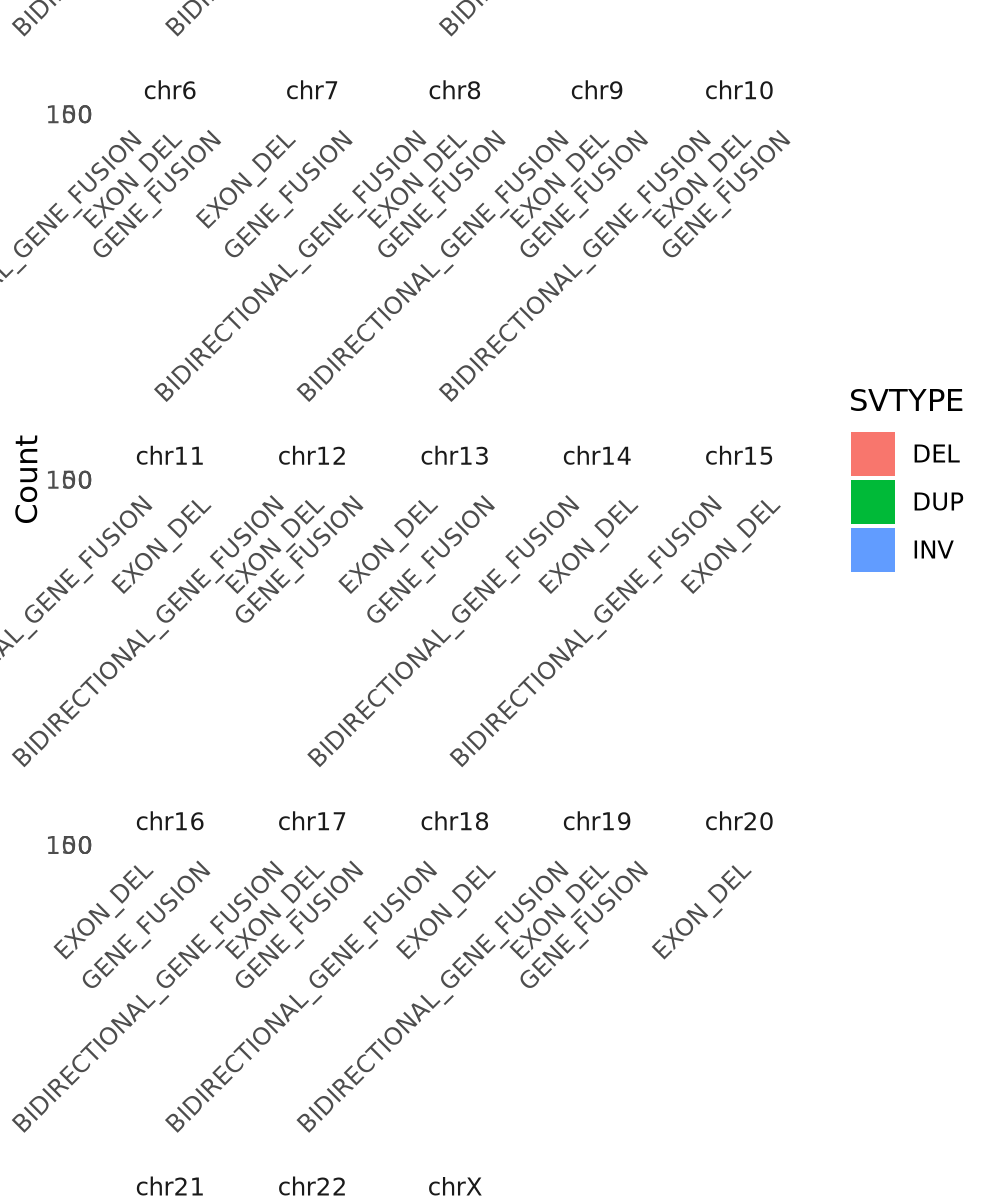

In [61]:
# Load required libraries
library(dplyr)
library(tidyr)
library(ggplot2)

# 1. Read TSV file
df <- read.delim("simple_ann.tsv", header=FALSE, col.names=c("CHROM", "POS", "SIMPLE_ANN"), stringsAsFactors=FALSE)

# 2. Filter out empty annotations, expand multiple annotations into rows
df_expanded <- df %>%
  filter(SIMPLE_ANN != "") %>%
  separate_rows(SIMPLE_ANN, sep = ",")

# 3. Parse SIMPLE_ANN into separate columns
df_parsed <- df_expanded %>%
  separate(SIMPLE_ANN, into = c("SVTYPE", "ANNOTATION", "GENE", "TRANSCRIPT", "DETAIL", "PRIORITY"), sep = "\\|", fill = "right")

# 4. Define CHM13 T2T chromosome accession to simple chromosome mapping
chrom_map <- c(
  "NC_060925.1" = "1",
  "NC_060926.1" = "2",
  "NC_060927.1" = "3",
  "NC_060928.1" = "4",
  "NC_060929.1" = "5",
  "NC_060930.1" = "6",
  "NC_060931.1" = "7",
  "NC_060932.1" = "8",
  "NC_060933.1" = "9",
  "NC_060934.1" = "10",
  "NC_060935.1" = "11",
  "NC_060936.1" = "12",
  "NC_060937.1" = "13",
  "NC_060938.1" = "14",
  "NC_060939.1" = "15",
  "NC_060940.1" = "16",
  "NC_060941.1" = "17",
  "NC_060942.1" = "18",
  "NC_060943.1" = "19",
  "NC_060944.1" = "20",
  "NC_060945.1" = "21",
  "NC_060946.1" = "22",
  "NC_060947.1" = "X",
  "NC_060948.1" = "Y"
)

# 5. Map chromosome accessions to simple names WITH "chr" prefix
df_parsed <- df_parsed %>%
  mutate(CHROM_simple = paste0("chr", chrom_map[CHROM]))

# 6. Filter out rows with NA ANNOTATION
df_filtered <- df_parsed %>%
  filter(!is.na(ANNOTATION))

# 7. Set factor levels for ordering chromosomes in plots
chrom_levels <- paste0("chr", c(as.character(1:22), "X", "Y"))
df_filtered <- df_filtered %>%
  mutate(CHROM_simple = factor(CHROM_simple, levels = chrom_levels))

# 8. Optional: Summarize counts by chromosome and annotation
annotation_counts_by_chr <- df_filtered %>%
  group_by(CHROM_simple, ANNOTATION) %>%
  summarise(Count = n(), .groups = "drop") %>%
  arrange(CHROM_simple, desc(Count))

print(annotation_counts_by_chr)

# 9. Plot: counts of ANNOTATION by SVTYPE, faceted by chromosome
ggplot(df_filtered, aes(x = ANNOTATION, fill = SVTYPE)) +
  geom_bar() +
  facet_wrap(~ CHROM_simple, scales = "free_x") +
  theme_minimal() +
  labs(title = "Counts of SIMPLE_ANN Annotation Types by SVTYPE and Chromosome",
       x = "Annotation Type",
       y = "Count") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


In [62]:
head(df_parsed)

CHROM,POS,SVTYPE,ANNOTATION,GENE,TRANSCRIPT,DETAIL,PRIORITY,CHROM_simple
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
NC_060925.1,296592,.,NA,NA,NA,NA,NA,chr1
NC_060925.1,305801,.,NA,NA,NA,NA,NA,chr1
NC_060925.1,325206,.,NA,NA,NA,NA,NA,chr1
NC_060925.1,364363,.,NA,NA,NA,NA,NA,chr1
NC_060925.1,364364,.,NA,NA,NA,NA,NA,chr1
NC_060925.1,364394,.,NA,NA,NA,NA,NA,chr1


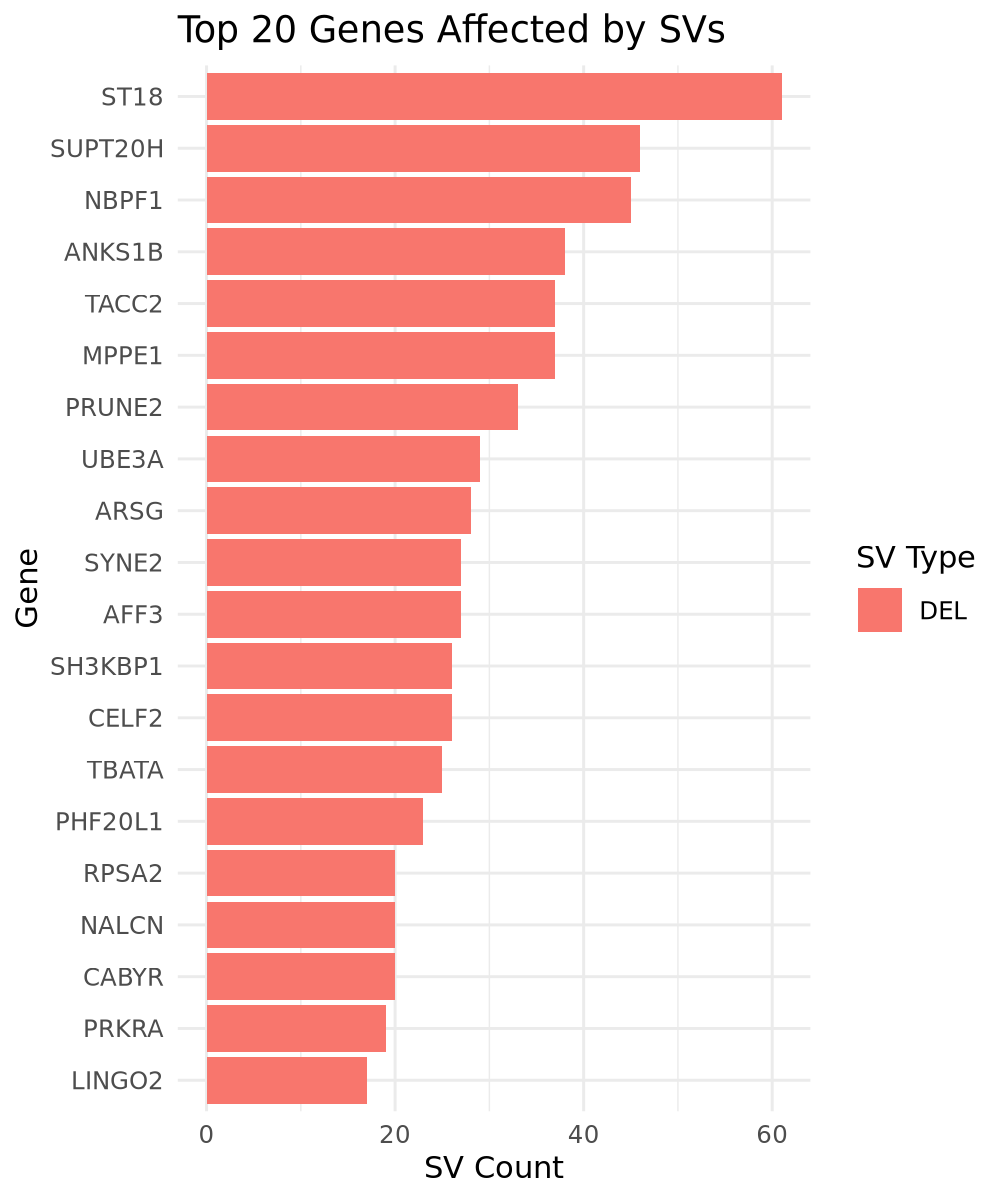

In [63]:
library(dplyr)
library(ggplot2)
library(forcats)
library(stringr)

# Assume df_filtered is your cleaned dataframe with required columns

# Step 1: Summarize SV counts per gene
gene_sv_counts <- df_filtered %>%
  filter(!is.na(GENE)) %>%
  group_by(GENE) %>%
  summarise(SV_count = n(), .groups = "drop") %>%
  arrange(desc(SV_count))

# Step 2: Select top 30 recurrent genes
top_genes <- gene_sv_counts %>%
  slice_max(SV_count, n = 20) %>%
  pull(GENE)

# Step 3: Filter data for top genes
df_top_genes <- df_filtered %>%
  filter(GENE %in% top_genes)

# Step 4: Barplot of SV counts per gene by SVTYPE
ggplot(df_top_genes, aes(x = reorder(GENE, SVTYPE, function(x) length(x)), fill = SVTYPE)) +
  geom_bar() +
  coord_flip() +
  theme_minimal() +
  labs(title = "Top 20 Genes Affected by SVs",
       x = "Gene",
       y = "SV Count",
       fill = "SV Type")




In [64]:
head(gene_sv_counts)

GENE,SV_count
<chr>,<int>
ST18,61
SUPT20H,46
NBPF1,45
ANKS1B,38
MPPE1,37
TACC2,37


In [65]:
head(df_plot)

ERROR: Error: object 'df_plot' not found


In [66]:
unique(df_plot$GENE)

ERROR: Error: object 'df_plot' not found


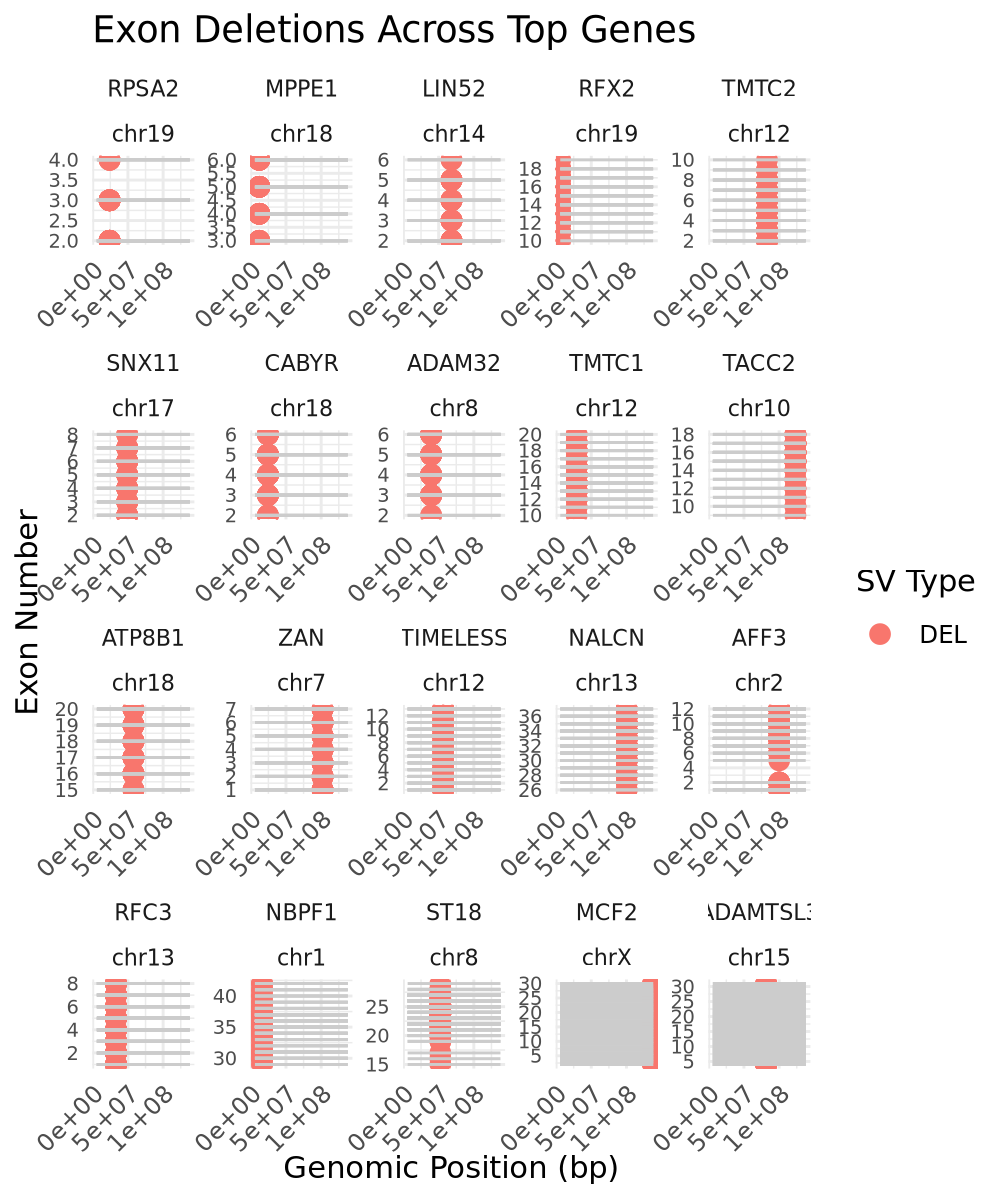

In [67]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(stringr)
library(forcats)

# Assume your dataframe is called df_filtered with columns including:
# CHROM_simple, POS, SVTYPE, GENE, DETAIL

# Step 1: Extract exon ranges and start/end exon numbers
df_exon_ranges <- df_filtered %>%
  filter(!is.na(DETAIL)) %>%
  mutate(
    exon_range = str_extract(DETAIL, "Exon[0-9]+-[0-9]+"),
    exon_start = as.integer(str_extract(exon_range, "(?<=Exon)[0-9]+")),
    exon_end = as.integer(str_extract(exon_range, "(?<=-)[0-9]+"))
  ) %>%
  filter(!is.na(exon_start) & !is.na(exon_end))

# Step 2: Expand rows for each exon in the range
df_exons_expanded <- df_exon_ranges %>%
  rowwise() %>%
  mutate(EXON = list(seq(exon_start, exon_end))) %>%
  unnest(EXON) %>%
  ungroup()

# Optional: select top genes by SV counts for plotting (adjust n as needed)
top_genes <- df_exons_expanded %>%
  count(GENE, sort = TRUE) %>%
  slice_max(n, n = 20) %>%
  pull(GENE)

df_plot <- df_exons_expanded %>%
  filter(GENE %in% top_genes) %>%
  mutate(GENE = factor(GENE, levels = rev(top_genes)))

# Step 3: Plot exon deletions per gene (lollipop style)
ggplot(df_plot, aes(x = POS, y = EXON, color = SVTYPE)) +
  geom_point(size = 3) +
  geom_segment(aes(x = min(POS), xend = max(POS), y = EXON, yend = EXON), color = "grey80") +
  facet_wrap(~ GENE + CHROM_simple, scales = "free") +
  scale_y_continuous(breaks = scales::pretty_breaks()) +
  theme_minimal() +
  labs(
    title = "Exon Deletions Across Top Genes",
    x = "Genomic Position (bp)",
    y = "Exon Number",
    color = "SV Type"
  ) +
  theme(
    strip.text = element_text(size = 8),
    axis.text.y = element_text(size = 7),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )


In [68]:
print(df_filtered)

# A tibble: 1,103 × 9
   CHROM     POS SVTYPE ANNOTATION GENE  TRANSCRIPT DETAIL PRIORITY CHROM_simple
   <chr>   <int> <chr>  <chr>      <chr> <chr>      <chr>  <chr>    <fct>       
 1 NC_06… 3.30e6 DEL    EXON_DEL   LRRC… NM_020710… Exon3… 3        chr1        
 2 NC_06… 1.60e7 DEL    EXON_DEL   NBPF1 NM_001405… Exon3… 3        chr1        
 3 NC_06… 1.60e7 DEL    EXON_DEL   NBPF1 NM_001405… Exon3… 3        chr1        
 4 NC_06… 1.60e7 DEL    EXON_DEL   NBPF1 NM_001405… Exon2… 3        chr1        
 5 NC_06… 1.60e7 DEL    EXON_DEL   NBPF1 NM_001405… Exon3… 3        chr1        
 6 NC_06… 1.60e7 DEL    EXON_DEL   NBPF1 NM_001405… Exon3… 3        chr1        
 7 NC_06… 1.60e7 DEL    EXON_DEL   NBPF1 NM_001405… Exon3… 3        chr1        
 8 NC_06… 1.60e7 DEL    EXON_DEL   NBPF1 NM_001405… Exon3… 3        chr1        
 9 NC_06… 1.60e7 DEL    EXON_DEL   NBPF1 NM_001405… Exon3… 3        chr1        
10 NC_06… 1.60e7 DEL    EXON_DEL   NBPF1 NM_001405… Exon3… 3        chr1        
# ℹ 1,

In [69]:
nrow(df_filtered)

[1] 1103

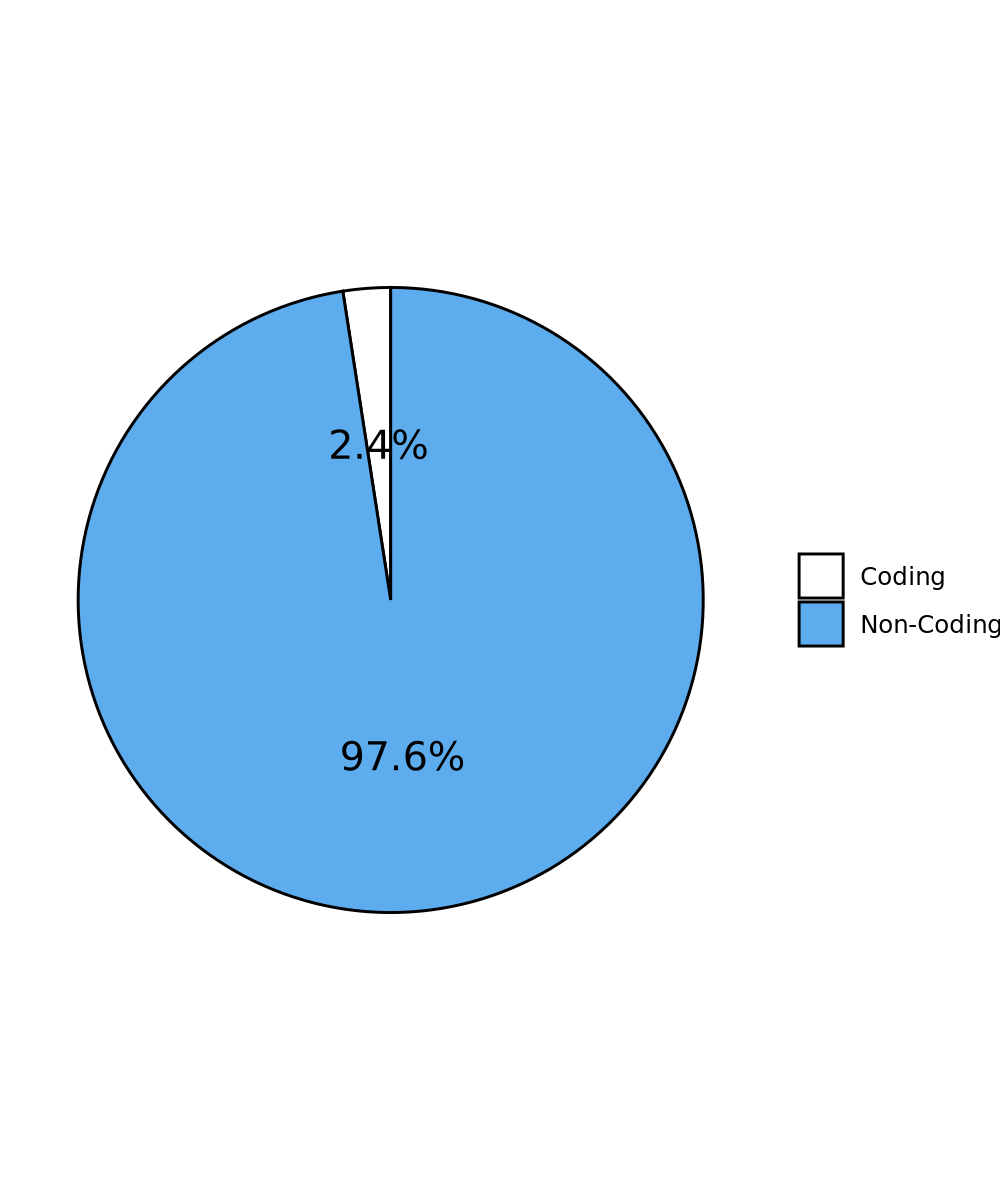

In [70]:
# Load libraries
library(ggplot2)
library(dplyr)

# Create the data
variant_counts <- data.frame(
  Category = c("Coding", "Non-Coding"),
  Count = c(11709, 478131 - 11709)  # 11,709 coding, rest non-coding
)

# Compute percentages and label
variant_counts <- variant_counts %>%
  mutate(
    Fraction = Count / sum(Count),
    PercentLabel = paste0(round(Fraction * 100, 1), "%")
  )

# Create pie chart
ggplot(variant_counts, aes(x = "", y = Fraction, fill = Category)) +
  geom_bar(stat = "identity", width = 1, color = "black") +
  coord_polar(theta = "y") +
  geom_text(aes(label = PercentLabel),
            position = position_stack(vjust = 0.5),
            size = 5, color = "black") +
  scale_fill_manual(values = c("Coding" = "white", "Non-Coding" = "steelblue2")) +
  theme_void() +
  theme(legend.title = element_blank())


In [71]:
priority_1_data <- df_filtered %>%
  filter(PRIORITY == "3")
print(priority_1_data)

# A tibble: 1,103 × 9
   CHROM     POS SVTYPE ANNOTATION GENE  TRANSCRIPT DETAIL PRIORITY CHROM_simple
   <chr>   <int> <chr>  <chr>      <chr> <chr>      <chr>  <chr>    <fct>       
 1 NC_06… 3.30e6 DEL    EXON_DEL   LRRC… NM_020710… Exon3… 3        chr1        
 2 NC_06… 1.60e7 DEL    EXON_DEL   NBPF1 NM_001405… Exon3… 3        chr1        
 3 NC_06… 1.60e7 DEL    EXON_DEL   NBPF1 NM_001405… Exon3… 3        chr1        
 4 NC_06… 1.60e7 DEL    EXON_DEL   NBPF1 NM_001405… Exon2… 3        chr1        
 5 NC_06… 1.60e7 DEL    EXON_DEL   NBPF1 NM_001405… Exon3… 3        chr1        
 6 NC_06… 1.60e7 DEL    EXON_DEL   NBPF1 NM_001405… Exon3… 3        chr1        
 7 NC_06… 1.60e7 DEL    EXON_DEL   NBPF1 NM_001405… Exon3… 3        chr1        
 8 NC_06… 1.60e7 DEL    EXON_DEL   NBPF1 NM_001405… Exon3… 3        chr1        
 9 NC_06… 1.60e7 DEL    EXON_DEL   NBPF1 NM_001405… Exon3… 3        chr1        
10 NC_06… 1.60e7 DEL    EXON_DEL   NBPF1 NM_001405… Exon3… 3        chr1        
# ℹ 1,

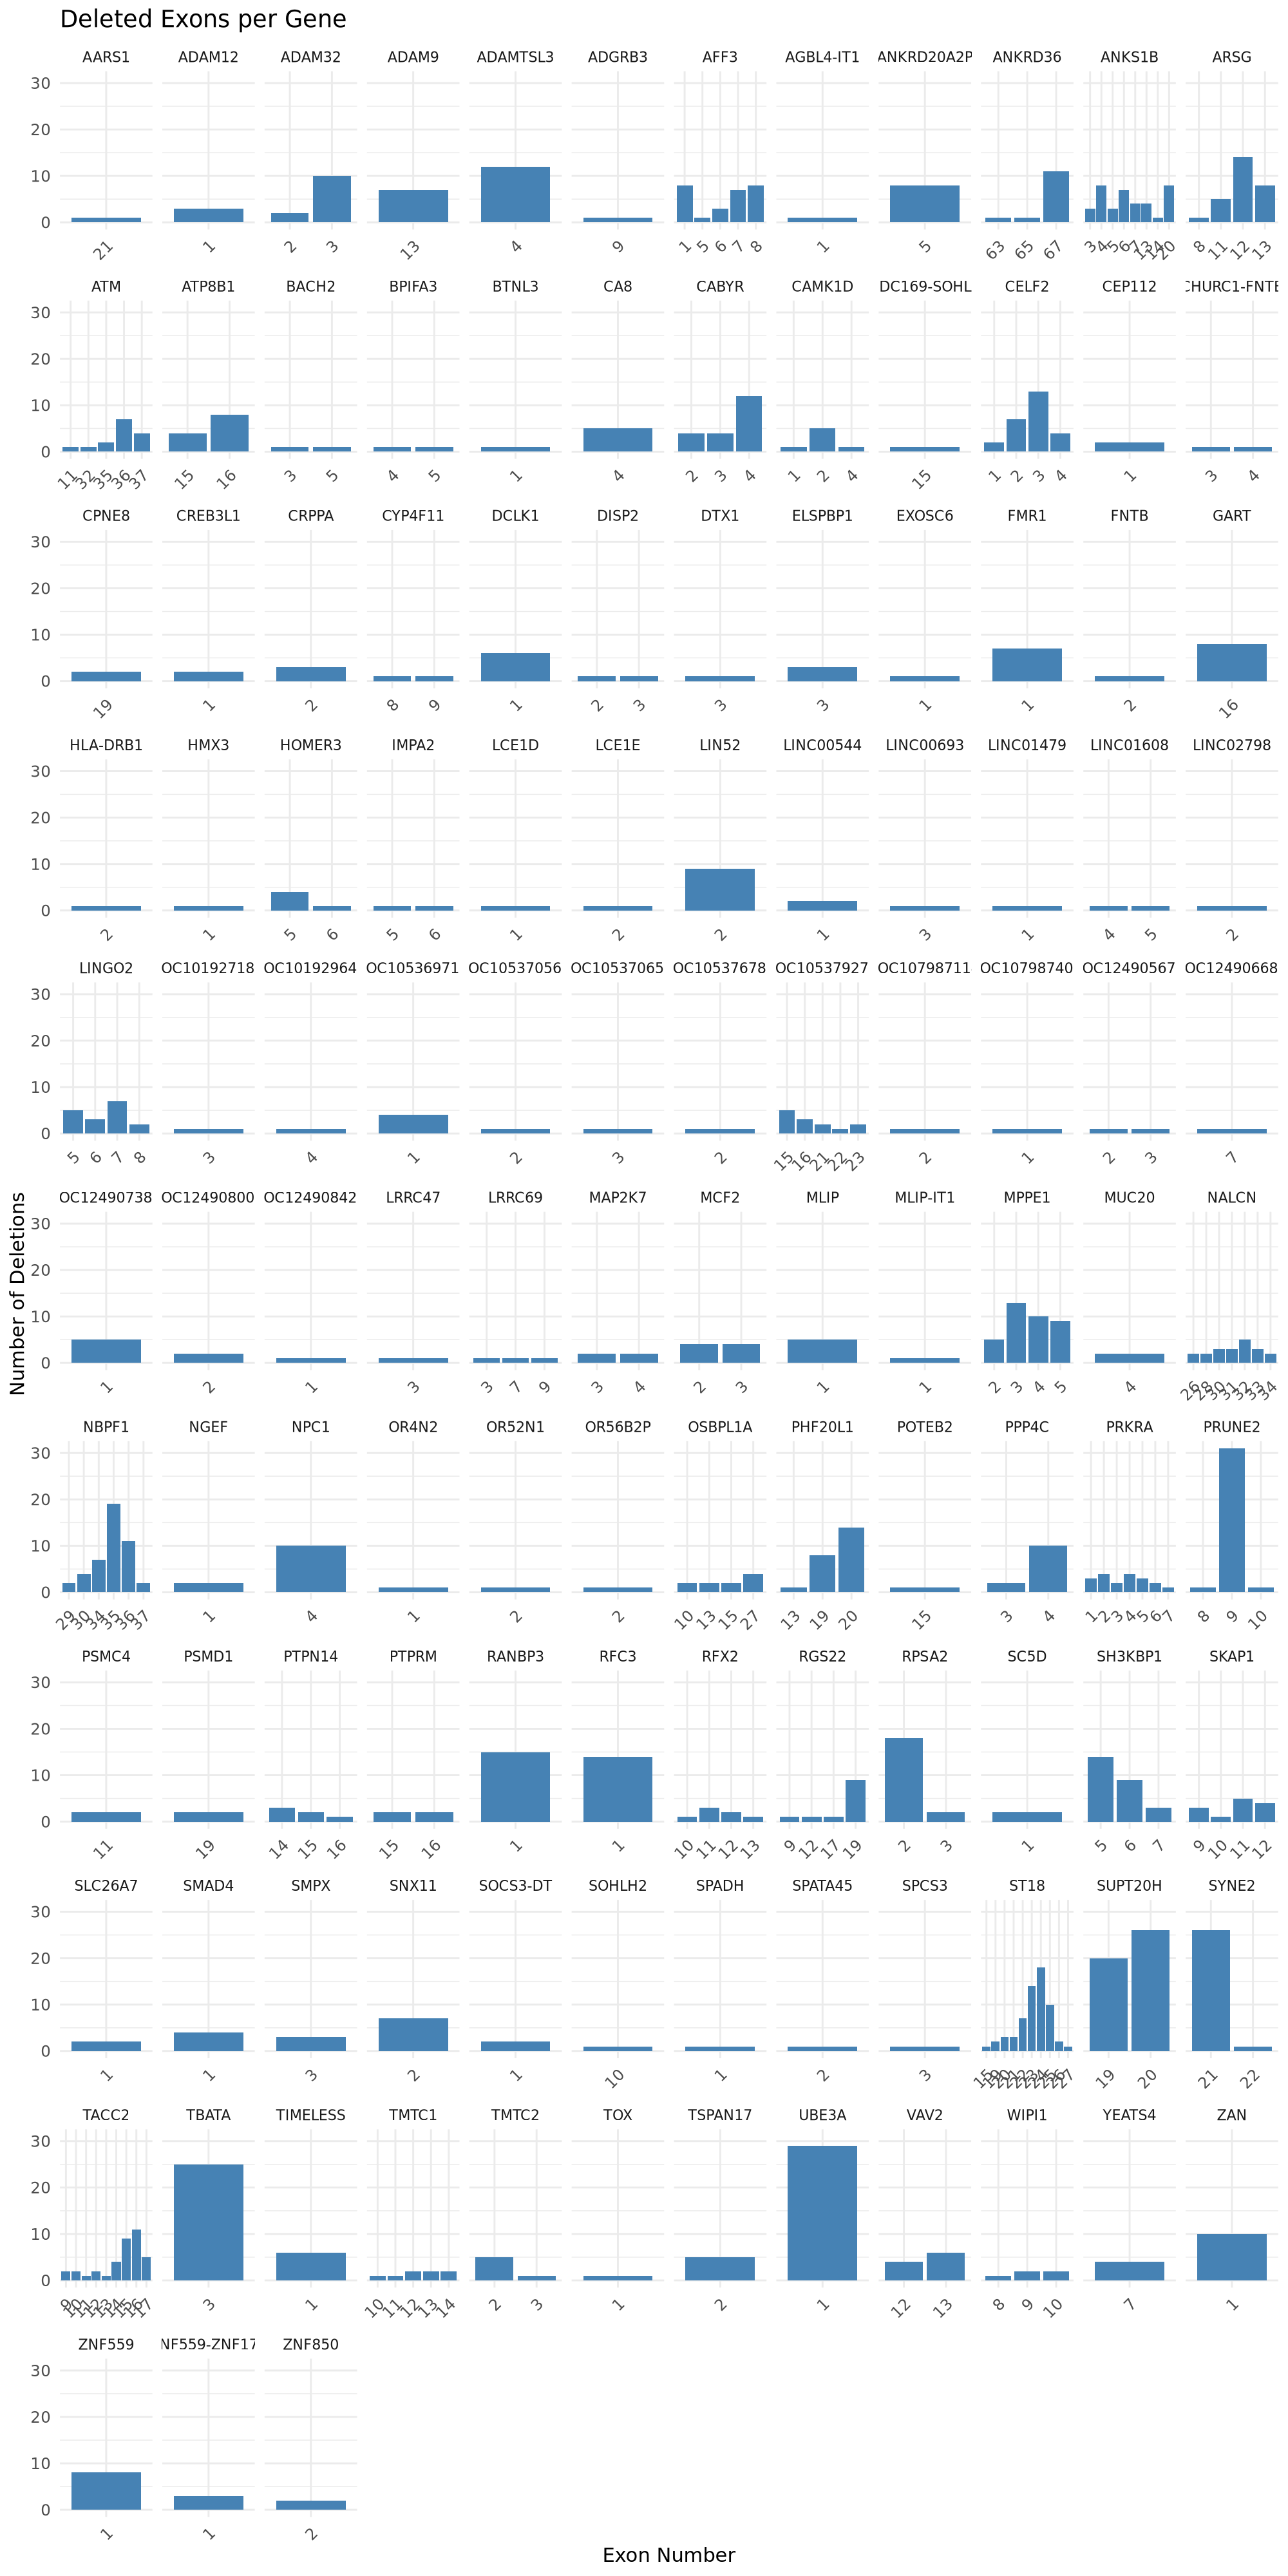

In [73]:
library(dplyr)
library(stringr)
library(ggplot2)

# Step 1: Extract exon number as integer
df_filtered <- df_filtered %>%
  mutate(
    Exon_num = str_extract(DETAIL, "(?<=Exon)\\d+"),
    Exon_num = as.integer(Exon_num)
  ) %>%
  filter(!is.na(Exon_num))  # keep only rows where exon number was found

# Step 2: Count deletions per gene-exon
exon_counts_all <- df_filtered %>%
  group_by(GENE, Exon_num) %>%
  summarise(Deletion_count = n(), .groups = "drop") %>%
  arrange(GENE, Exon_num)

options(repr.plot.width = 10, repr.plot.height = 20, repr.plot.res = 200)


# Step 3: Plot with facets by gene
ggplot(exon_counts_all, aes(x = factor(Exon_num), y = Deletion_count)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  facet_wrap(~ GENE, scales = "free_x") +  # each gene gets own facet, scales free for exon axis
  labs(
    title = "Deleted Exons per Gene",
    x = "Exon Number",
    y = "Number of Deletions"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text = element_text(size = 8)
  )
